#### External validation of the GPT task orderings against observed process-mining event logs
#### By: Peyman Shahidi
#### Created: 2026-07-31

**Idea.** The APQC exercise (`apqc_pcf_orderingValidation.ipynb`) scores our ordering instrument against
sequences that practitioners *documented*. That benchmark has a known weakness, conceded in the appendix:
a documented ordering is an editorial convention, and for branches whose children are parallel or mutually
exclusive no true order exists at all, so disagreement there carries no information.

Event logs remove that weakness. A process-mining log records, case by case, the activities a real
organisation actually executed and when. The ordering is therefore **observed rather than asserted**, and,
crucially, the data tell us *which pairs of activities genuinely have an order*: if activity $x$ precedes
$y$ in 97% of cases the precedence is real, whereas a 50/50 split means the two run concurrently and no
ordering instrument could or should get it "right".

This lets us do the thing the APQC design could not: restrict attention to the pairs that are determinate in
observed execution, and ask how often the model puts those in the right direction.

**Design.** For each log we recover the activity set, the observed ordering, and the full pairwise precedence
matrix from the raw traces. We then shuffle the activity names, hand them to GPT-5-mini under the **same
eleven prompts** used for O\*NET and for APQC (main prompt plus the ten alternatives of the prompt-robustness
appendix), and score the returned ordering against what the organisations actually did.

**Logs.** Eight public logs from the 4TU.ResearchData repository, spanning fine collection, hospital sepsis
care, consumer lending, and university travel reimbursement. They are considerably longer than the APQC
branches (10 to 30 activities against a median of 5), so they also test the instrument on long sequences.

**Outputs.** `data/computed_objects/eventlog_ordering/`, `writeup/plots/eventlog_ordering/`, and
`writeup/tables/eventlog_ordering_validation.tex`.

In [1]:
#Python
import os, json, gzip, glob, itertools, collections, warnings
import numpy as np, pandas as pd
import xml.etree.ElementTree as ET
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 220)

In [2]:
MIN_CASE_SHARE = 0.02     # keep activities appearing in at least 2% of cases
MIN_ACTIVITIES = 5        # logs need at least this many surviving activities
DETERMINATE    = 0.80     # a pair counts as strictly ordered if one direction holds in >= 80% of cases
N_SHUFFLES     = 1000     # permutation null draws per log
SEED           = 123
RUN_GPT        = True

MAIN_PROMPT = 'p00'
ALT_PROMPTS = [f'p{i:02d}' for i in range(1, 11)]
PROMPT_IDS  = [MAIN_PROMPT] + ALT_PROMPTS

main_folder_path  = ".."
input_data_path   = f"{main_folder_path}/data"
log_path          = f"{input_data_path}/process_mining"
output_data_path  = f"{input_data_path}/computed_objects/eventlog_ordering"
gpt_cache_path    = f"{output_data_path}/gpt_orderings"
output_plot_path  = f"{main_folder_path}/writeup/plots/eventlog_ordering"
output_table_path = f"{main_folder_path}/writeup/tables"
for p in [output_data_path, output_plot_path, output_table_path] + [f"{gpt_cache_path}/{v}" for v in PROMPT_IDS]:
    os.makedirs(p, exist_ok=True)

# Each log, with the plain-English process description handed to the model in place of an occupation title.
LOGS = {
    'roadfine':               'Road traffic fine management by a local police force',
    'sepsis':                 'Treatment of patients with suspected sepsis in a hospital emergency department',
    'bpi2017_loan':           'Loan application handling at a financial institution',
    'bpi2020_domestic':       'Domestic travel expense declaration handling at a university',
    'bpi2020_international':  'International travel expense declaration handling at a university',
    'bpi2020_requestpayment': 'Request for payment handling at a university',
    'bpi2020_prepaid':        'Prepaid travel cost handling at a university',
    'bpi2020_permit':         'Travel permit and expense declaration handling at a university',
}

# 1) Recover the observed ordering from the raw traces

Each log is streamed from its XES file and reduced to one trace per case: the sequence of activity labels in
timestamp order. We keep activities occurring in at least `MIN_CASE_SHARE` of cases, so that the ordering
target is not driven by rare exceptions, and we use each activity's **first** occurrence within a case, which
handles the loops that appear in every real log (repeated lab tests, repeated approval rounds).

Two objects come out of this, and the second is what distinguishes this exercise from the APQC one.

1. **The observed ordering**: activities ranked by their mean normalised first-occurrence position across
   cases. This is the analogue of APQC's published order and is what we score Kendall's $\tau$ against.
2. **The pairwise precedence matrix**: for every pair $(x, y)$, the share of cases containing both in which
   $x$ precedes $y$. A share near $1$ or $0$ means the precedence is real; a share near $0.5$ means the two
   activities run concurrently and no ordering can be correct. We call a pair **determinate** when one
   direction holds in at least `DETERMINATE` of cases.

In [3]:
XES_NS = '{http://www.xes-standard.org/}'

def stream_traces(path):
    '''Yield one list of activity labels per case, in timestamp order, without loading the file.'''
    opener = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rb') as fh:
        cur = None
        for ev, el in ET.iterparse(fh, events=('start', 'end')):
            tag = el.tag.replace(XES_NS, '')
            if ev == 'start' and tag == 'trace':
                cur = []
            elif ev == 'end' and tag == 'event' and cur is not None:
                name = next((c.get('value') for c in el if c.get('key') == 'concept:name'), None)
                if name:
                    cur.append(name)
                el.clear()
            elif ev == 'end' and tag == 'trace':
                yield cur
                cur = None
                el.clear()

def summarise_log(path):
    '''Observed ordering and pairwise precedence, from first occurrences within each case.'''
    traces = [t for t in stream_traces(path) if len(t) >= 2]
    n_cases = len(traces)
    coverage = collections.Counter()
    for t in traces:
        coverage.update(set(t))
    keep = {a for a, c in coverage.items() if c / n_cases >= MIN_CASE_SHARE}

    positions = collections.defaultdict(list)
    before, both = collections.Counter(), collections.Counter()
    for t in traces:
        first = {}
        for i, a in enumerate(t):
            if a in keep and a not in first:
                first[a] = i
        if len(first) < 2:
            continue
        span = max(first.values()) or 1
        for a, i in first.items():
            positions[a].append(i / span)
        for x, y in itertools.combinations(sorted(first), 2):
            both[(x, y)] += 1
            before[(x, y) if first[x] < first[y] else (y, x)] += 1

    order = sorted(keep, key=lambda a: np.mean(positions[a]))
    pairs = []
    for (x, y), n in both.items():
        p = before[(x, y)] / n
        pairs.append({'act_x': x, 'act_y': y, 'n_cases_both': n, 'share_x_before_y': p,
                      'determinacy': 2 * abs(p - 0.5), 'is_determinate': max(p, 1 - p) >= DETERMINATE})
    return {'n_cases': n_cases, 'n_events': sum(len(t) for t in traces),
            'activities': order,
            'mean_position': {a: float(np.mean(positions[a])) for a in order},
            'coverage': {a: coverage[a] / n_cases for a in order},
            'pairs': pairs}

In [4]:
logs = {}
for name in LOGS:
    cache = f"{output_data_path}/{name}_summary.json"
    if os.path.exists(cache):
        logs[name] = json.load(open(cache))
    else:
        path = glob.glob(f"{log_path}/{name}__*.xes*")[0]
        print(f"parsing {name} ...", flush=True)
        logs[name] = summarise_log(path)
        json.dump(logs[name], open(cache, 'w'))

logs = {k: v for k, v in logs.items() if len(v['activities']) >= MIN_ACTIVITIES}

rows = []
for name, L in logs.items():
    det = [p for p in L['pairs'] if p['is_determinate']]
    rows.append({'log': name, 'process': LOGS[name], 'cases': L['n_cases'], 'events': L['n_events'],
                 'activities': len(L['activities']), 'pairs': len(L['pairs']),
                 'determinate_pairs': len(det), 'share_determinate': len(det) / len(L['pairs'])})
overview = pd.DataFrame(rows)
overview.to_csv(f"{output_data_path}/log_overview.csv", index=False)
print(overview.to_string(index=False))
print(f"\ntotal: {overview['cases'].sum():,} cases | {overview['events'].sum():,} events | "
      f"{overview['pairs'].sum():,} activity pairs, of which {overview['determinate_pairs'].sum():,} "
      f"({overview['determinate_pairs'].sum() / overview['pairs'].sum():.1%}) are determinate")

                   log                                                                        process  cases  events  activities  pairs  determinate_pairs  share_determinate
              roadfine                           Road traffic fine management by a local police force 150370  561470           8     28                 27           0.964286
                sepsis Treatment of patients with suspected sepsis in a hospital emergency department   1050   15214          15     98                 91           0.928571
          bpi2017_loan                           Loan application handling at a financial institution  31509 1202267          23    245                238           0.971429
      bpi2020_domestic                   Domestic travel expense declaration handling at a university  10366   56303          10     44                 41           0.931818
 bpi2020_international              International travel expense declaration handling at a university   6449   72151          22  

# 2) GPT-5-mini orderings under all eleven prompts

The prompt bodies are copied verbatim from `onet_task_and_occ_sequence_robustness.ipynb`, with the same
mechanical substitution used in the APQC exercise mapping the occupation domain onto the process domain. The
model sees the activity labels exactly as they appear in the log, shuffled under a fixed seed, together with
the one-line process description. No log is given hints about which activity starts or ends a case.

In [5]:
from dotenv import load_dotenv
load_dotenv(f"{main_folder_path}/.env")
from edsl import QuestionFreeText, Scenario, Model
from textwrap import dedent

PREFIX = dedent("""\
    You are an expert in workflow analysis for the occupation: {{ occupation }}.
    Below is a list of {{ num_tasks }} tasks that are part of this occupation:
    {{ tasks_list }}
    """)
RETURN_SPEC = dedent("""\
    Return your answer as a JSON array where each element has:
    - "Task Position": the sequence number (1, 2, 3, etc.)
    - "Task Title": the exact task text from the list above
    Format: [{"Task Position": 1, "Task Title": "..."}, {"Task Position": 2, "Task Title": "..."}, ...]
    Only return the JSON array, nothing else.
    """)
USER_PROMPTS = [
    'Provide the typical sequential order in which these tasks are performed in a real-world workflow.',
    'Imagine a typical workday for this occupation. As the day unfolds, tasks arise and are completed as needed. Order the tasks in the sequence they most naturally occur.',
    'For each task, consider its inputs and outputs. Order tasks so outputs of earlier tasks plausibly feed into later tasks. If tasks are parallel, place the more upstream task first.',
    'Order tasks to minimize rework, waiting, and unnecessary handoffs. Assume an experienced worker executing the workflow efficiently.',
    'Think about what must ultimately be produced in this occupation and what needs to happen before that. Use this reasoning to produce a natural forward sequence of tasks.',
    'Identify which tasks logically depend on others, then order the tasks in a single sequence consistent with those dependencies and typical practice.',
    'Order tasks according to how information is generated, transformed, and used over the course of the work.',
    'Order tasks based on when mistakes would be most costly, placing tasks that prevent or constrain downstream errors earlier.',
    'Order tasks so that tasks informing important decisions tend to occur before tasks that rely on those decisions.',
    'Order the tasks as an experienced practitioner would intuitively carry them out, without explicitly planning or formalizing the workflow.',
    'Order the tasks to reflect how the work is most commonly carried out in practice, rather than how it is formally described.',
]

def to_process_domain(text):
    for a, b in [('{{ occupation }}', '{{ process }}'), ('{{ num_tasks }}', '{{ num_steps }}'),
                 ('{{ tasks_list }}', '{{ steps_list }}'), ('Task Position', 'Step Position'),
                 ('Task Title', 'Step Title'), ('occupation', 'business process'),
                 ('tasks', 'steps'), ('task', 'step')]:
        text = text.replace(a, b)
    return text

PROMPT_TEXT = {f"p{i:02d}": to_process_domain(PREFIX + "\n" + up + "\n" + RETURN_SPEC)
               for i, up in enumerate(USER_PROMPTS)}

rng_shuffle = np.random.default_rng(SEED)
shown_order = {name: list(rng_shuffle.permutation(L['activities'])) for name, L in logs.items()}

In [6]:
def build_scenario(name):
    shown = shown_order[name]
    return Scenario({'log_id': f'id:{name}', 'process': LOGS[name], 'num_steps': len(shown),
                     'steps_list': "\n".join(f"{i}. {a}" for i, a in enumerate(shown, 1))})

def parse_answer(raw, name):
    '''Return {activity: gpt_position} or None if the answer is not a complete permutation.'''
    if not isinstance(raw, str):
        return None
    try:
        parsed = json.loads(raw.replace('```json', '').replace('```', '').strip())
    except json.JSONDecodeError:
        return None
    valid = set(logs[name]['activities'])
    out = {}
    for e in parsed:
        a = str(e.get('Step Title', '')).strip()
        if a in valid and a not in out:
            out[a] = int(e['Step Position'])
    return out if len(out) == len(valid) else None

def run_prompt(pid):
    todo = [n for n in logs if not os.path.exists(f"{gpt_cache_path}/{pid}/{n}.csv")]
    if not todo:
        print(f"[{pid}] complete ({len(logs)} cached)")
        return
    if not RUN_GPT:
        print(f"[{pid}] {len(todo)} missing, RUN_GPT is False")
        return
    q = QuestionFreeText(question_name="step_sequence", question_text=PROMPT_TEXT[pid])
    model = Model("gpt-5-mini", service_name="openai_v2", temperature=0.0, max_tokens=16000)
    res = q.by(model).by([build_scenario(n) for n in todo]).run(progress_bar=False)
    failed = []
    for _, r in res.to_pandas().iterrows():
        n = str(r['scenario.log_id']).removeprefix('id:')
        got = parse_answer(r['answer.step_sequence'], n)
        if got is None:
            failed.append(n)
        else:
            (pd.DataFrame({'activity': list(got), 'gpt_position': list(got.values())})
             .sort_values('gpt_position').to_csv(f"{gpt_cache_path}/{pid}/{n}.csv", index=False))
    print(f"[{pid}] {len(glob.glob(f'{gpt_cache_path}/{pid}/*.csv'))}/{len(logs)} cached"
          + (f" | unparsed: {failed}" if failed else ""))

for pid in PROMPT_IDS:
    run_prompt(pid)

gpt_pos = {pid: {os.path.basename(f)[:-4]: dict(zip(pd.read_csv(f)['activity'],
                                                    pd.read_csv(f)['gpt_position']))
                 for f in glob.glob(f"{gpt_cache_path}/{pid}/*.csv")} for pid in PROMPT_IDS}
print("\nrecovered:", {pid: len(v) for pid, v in gpt_pos.items()})

[p00] complete (8 cached)
[p01] complete (8 cached)
[p02] complete (8 cached)
[p03] complete (8 cached)
[p04] complete (8 cached)
[p05] complete (8 cached)
[p06] complete (8 cached)
[p07] complete (8 cached)
[p08] complete (8 cached)
[p09] complete (8 cached)
[p10] complete (8 cached)

recovered: {'p00': 8, 'p01': 8, 'p02': 8, 'p03': 8, 'p04': 8, 'p05': 8, 'p06': 8, 'p07': 8, 'p08': 8, 'p09': 8, 'p10': 8}


# 3) Scoring

Two levels of analysis.

**Log level.** Kendall's $\tau$ between the model's ordering and the observed ordering, directly comparable
to the APQC numbers, benchmarked against a permutation null of random orderings of the same activity set.

**Pair level.** For every activity pair we ask only whether the model puts it in the direction the traces
actually show. This is the statistic the event logs make available and the APQC data does not, because here
we can condition on the pairs that have a real order. We report it three ways: over all pairs, over
determinate pairs alone, and weighted by determinacy so that a 97/3 pair counts for more than a 55/45 pair.
Pair-level accuracy is also the statistic closest to what the paper's predictions actually use, since
Predictions~\#1 and~\#3 depend on adjacency rather than on the global ordering.

In [7]:
rng = np.random.default_rng(SEED)
log_rows, pair_rows, null_by_log = [], [], {}

for name, L in logs.items():
    acts = L['activities']
    observed = {a: i for i, a in enumerate(acts)}          # already in observed order
    shown = {a: i for i, a in enumerate(shown_order[name])}
    row = {'log': name, 'process': LOGS[name], 'n_activities': len(acts),
           'n_cases': L['n_cases'], 'n_pairs': len(L['pairs'])}

    for pid in PROMPT_IDS:
        gp = gpt_pos[pid].get(name)
        if gp is None:
            row[f'tau_{pid}'] = np.nan
            continue
        row[f'tau_{pid}'] = float(kendalltau([observed[a] for a in acts], [gp[a] for a in acts])[0])
        adj = {(acts[i], acts[i + 1]) for i in range(len(acts) - 1)}   # adjacent in the observed order
        for p in L['pairs']:
            x, y = p['act_x'], p['act_y']
            gpt_says_x_first = gp[x] < gp[y]
            truth_x_first = p['share_x_before_y'] >= 0.5
            pair_rows.append({'log': name, 'prompt': pid, 'act_x': x, 'act_y': y,
                              'n_cases_both': p['n_cases_both'], 'determinacy': p['determinacy'],
                              'is_determinate': p['is_determinate'],
                              'is_adjacent': (x, y) in adj or (y, x) in adj,
                              'correct': bool(gpt_says_x_first == truth_x_first)})

    row['tau_alt_mean'] = float(np.nanmean([row[f'tau_{p}'] for p in ALT_PROMPTS]))
    row['tau_main'] = row[f'tau_{MAIN_PROMPT}']
    if gpt_pos[MAIN_PROMPT].get(name):
        gp = gpt_pos[MAIN_PROMPT][name]
        row['tau_vs_presented'] = float(kendalltau([shown[a] for a in acts], [gp[a] for a in acts])[0])
    draws = np.array([kendalltau(np.arange(len(acts)), rng.permutation(len(acts)))[0]
                      for _ in range(N_SHUFFLES)])
    null_by_log[name] = draws
    row['tau_null_mean'] = float(draws.mean()); row['tau_null_sd'] = float(draws.std(ddof=1))
    log_rows.append(row)

res = pd.DataFrame(log_rows)
pairs = pd.DataFrame(pair_rows)
res.to_csv(f"{output_data_path}/log_level_results.csv", index=False)
pairs.to_csv(f"{output_data_path}/pair_level_results.csv", index=False)
print(res[['log', 'n_activities', 'n_cases', 'tau_main', 'tau_alt_mean', 'tau_vs_presented']].round(3).to_string(index=False))

                   log  n_activities  n_cases  tau_main  tau_alt_mean  tau_vs_presented
              roadfine             8   150370     0.857         0.714             0.071
                sepsis            15     1050     0.771         0.707            -0.086
          bpi2017_loan            23    31509     0.391         0.350             0.067
      bpi2020_domestic            10    10366    -0.022         0.182             0.244
 bpi2020_international            22     6449     0.775         0.844            -0.004
bpi2020_requestpayment            10     6814    -0.022         0.036            -0.289
       bpi2020_prepaid            17     2092     0.721         0.721            -0.074
        bpi2020_permit            28     7065     0.381         0.374             0.127


In [8]:
def pair_stats(df):
    d = df[df['is_determinate']]
    return pd.Series({
        'n_pairs': len(df),
        'accuracy_all_pairs': df['correct'].mean(),
        'n_determinate': len(d),
        'accuracy_determinate': d['correct'].mean(),
        'accuracy_weighted': np.average(df['correct'], weights=df['determinacy']) if df['determinacy'].sum() else np.nan,
        'n_adjacent': int(df['is_adjacent'].sum()),
        'accuracy_adjacent': df.loc[df['is_adjacent'], 'correct'].mean(),
    })

main_pairs = pairs[pairs['prompt'] == MAIN_PROMPT]
alt_pairs  = pairs[pairs['prompt'].isin(ALT_PROMPTS)]

print("=== PAIR-LEVEL: does the model put the pair in the direction the traces show? (null 0.500) ===\n")
for lab, df in [('Main prompt', main_pairs), ('All 10 alternative prompts pooled', alt_pairs)]:
    s = pair_stats(df)
    print(f"{lab}")
    print(f"   all pairs           {s['accuracy_all_pairs']:.3f}   (n={int(s['n_pairs']):,})")
    print(f"   determinate pairs   {s['accuracy_determinate']:.3f}   (n={int(s['n_determinate']):,}, "
          f"{s['n_determinate']/s['n_pairs']:.0%} of pairs)")
    print(f"   determinacy-weighted{s['accuracy_weighted']:.3f}")
    print(f"   adjacent pairs only {s['accuracy_adjacent']:.3f}   (n={int(s['n_adjacent']):,}) "
          f"<- the statistic directly comparable to the APQC exercise\n")

print("=== accuracy by how determinate the pair is (main prompt) ===")
band = pd.cut(main_pairs['determinacy'], [0, .2, .4, .6, .8, 1.0],
              labels=['0.0-0.2 (concurrent)', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0 (strict)'],
              include_lowest=True)
print(main_pairs.assign(band=band).groupby('band', observed=True)
      .agg(pairs=('correct', 'size'), accuracy=('correct', 'mean')).round(3).to_string())

print("\n=== per-log pair accuracy, main prompt ===")
per_log = main_pairs.groupby('log').apply(pair_stats).round(3)
print(per_log.to_string())
per_log.to_csv(f"{output_data_path}/pair_accuracy_by_log.csv")

print("\n=== per-prompt pair accuracy on determinate pairs ===")
pp = (pairs[pairs['is_determinate']].groupby('prompt')['correct'].agg(['size', 'mean']).round(3)
      .rename(columns={'size': 'determinate_pairs', 'mean': 'accuracy'}))
print(pp.to_string())
pp.to_csv(f"{output_data_path}/pair_accuracy_by_prompt.csv")

=== PAIR-LEVEL: does the model put the pair in the direction the traces show? (null 0.500) ===

Main prompt
   all pairs           0.788   (n=1,178)
   determinate pairs   0.789   (n=1,124, 95% of pairs)
   determinacy-weighted0.788
   adjacent pairs only 0.679   (n=109) <- the statistic directly comparable to the APQC exercise

All 10 alternative prompts pooled
   all pairs           0.791   (n=11,780)
   determinate pairs   0.792   (n=11,240, 95% of pairs)
   determinacy-weighted0.792
   adjacent pairs only 0.699   (n=1,090) <- the statistic directly comparable to the APQC exercise

=== accuracy by how determinate the pair is (main prompt) ===
                      pairs  accuracy
band                                 
0.0-0.2 (concurrent)      6     0.500
0.2-0.4                  23     0.826
0.4-0.6                  25     0.760
0.6-0.8                  95     0.874
0.8-1.0 (strict)       1029     0.781

=== per-log pair accuracy, main prompt ===
                        n_pairs  acc

In [9]:
print("=== LOG-LEVEL: Kendall tau against the observed ordering ===\n")
for lab, col in [('Main prompt', 'tau_main'), ('Average of 10 alternative prompts', 'tau_alt_mean'),
                 ('Random ordering (null)', 'tau_null_mean')]:
    s = res[col]
    print(f"{lab:<36} mean tau {s.mean():+.3f} | median {s.median():+.3f} | "
          f"min {s.min():+.3f} | max {s.max():+.3f}")

agg_null = np.column_stack([null_by_log[n] for n in res['log']]).mean(axis=1)
mu, sd = agg_null.mean(), agg_null.std(ddof=1)
summary = []
for lab, col in [('mean tau, main prompt', 'tau_main'),
                 ('mean tau, average of 10 alternative prompts', 'tau_alt_mean')]:
    obs = float(res[col].mean())
    z = (obs - mu) / sd
    p = (1 + int((agg_null >= obs).sum())) / (1 + N_SHUFFLES)
    summary.append({'statistic': lab, 'observed': obs, 'null_mean': mu, 'null_sd': sd, 'z': z,
                    'p_onesided_greater': p, 'n_logs': len(res)})
    print(f"\n{lab:<44} observed {obs:+.3f} | null {mu:+.3f} (sd {sd:.4f}) | z = {z:.1f} | p = {p:.4f}")

for lab, df in [('main prompt', main_pairs), ('10 alternative prompts', alt_pairs)]:
    s = pair_stats(df)
    summary.append({'statistic': f'determinate-pair precedence accuracy, {lab}',
                    'observed': s['accuracy_determinate'], 'null_mean': 0.5, 'null_sd': np.nan,
                    'z': np.nan, 'p_onesided_greater': np.nan, 'n_logs': len(res)})

print(f"\necho check, main prompt vs the shuffled list it was shown: mean tau "
      f"{res['tau_vs_presented'].mean():+.3f}")
print(f"per-prompt log-level means span {min(res[f'tau_{p}'].mean() for p in PROMPT_IDS):+.3f} to "
      f"{max(res[f'tau_{p}'].mean() for p in PROMPT_IDS):+.3f}")
pd.DataFrame(summary).to_csv(f"{output_data_path}/summary_stats.csv", index=False)

=== LOG-LEVEL: Kendall tau against the observed ordering ===

Main prompt                          mean tau +0.481 | median +0.556 | min -0.022 | max +0.857
Average of 10 alternative prompts    mean tau +0.491 | median +0.540 | min +0.036 | max +0.844
Random ordering (null)               mean tau -0.002 | median -0.003 | min -0.007 | max +0.006

mean tau, main prompt                        observed +0.481 | null -0.002 (sd 0.0711) | z = 6.8 | p = 0.0010

mean tau, average of 10 alternative prompts  observed +0.491 | null -0.002 (sd 0.0711) | z = 6.9 | p = 0.0010

echo check, main prompt vs the shuffled list it was shown: mean tau +0.007
per-prompt log-level means span +0.433 to +0.559


# 4) Plots

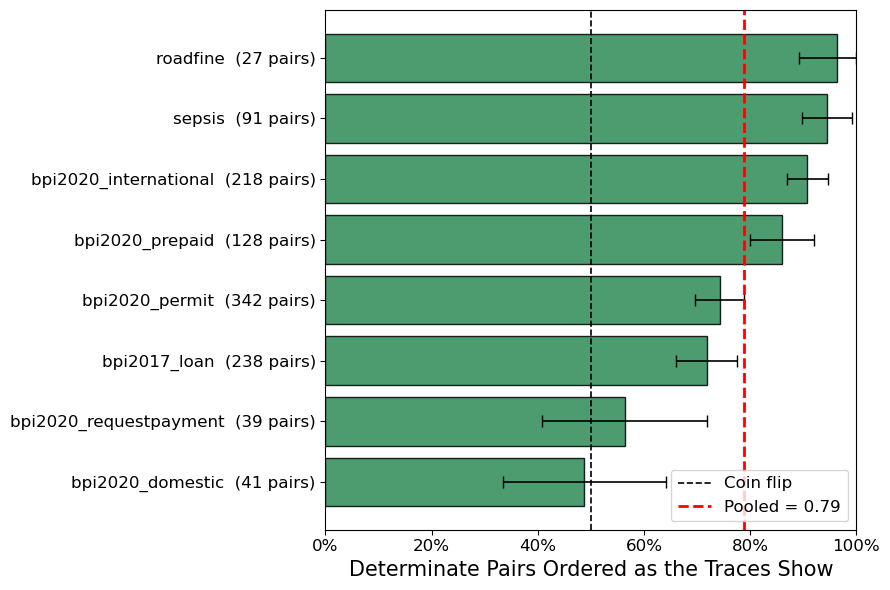

In [10]:
# Per-log precedence accuracy on determinate pairs, with binomial 95% intervals.
# (A profile of accuracy against determinacy is not shown: 95% of pairs fall in the top determinacy
#  band, so the remaining bands hold 1 to 25 pairs each and carry no signal. The banded numbers are
#  printed above with their counts.)
def binom_ci(k, n):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    se = np.sqrt(p * (1 - p) / n)
    return (max(0, p - 1.96 * se), min(1, p + 1.96 * se))

det_main = main_pairs[main_pairs['is_determinate']]
per = (det_main.groupby('log')['correct'].agg(['size', 'sum', 'mean'])
       .rename(columns={'size': 'n', 'sum': 'k', 'mean': 'acc'}).reset_index().sort_values('acc'))
per[['lo', 'hi']] = per.apply(lambda r: pd.Series(binom_ci(r['k'], r['n'])), axis=1)
pooled = det_main['correct'].mean()

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(per))
ax.barh(y, per['acc'], color='seagreen', alpha=0.85, edgecolor='black')
ax.errorbar(per['acc'], y, xerr=[per['acc'] - per['lo'], per['hi'] - per['acc']],
            fmt='none', ecolor='black', capsize=4, lw=1.2)
ax.axvline(0.5, color='black', ls='--', lw=1.2, label='Coin flip')
ax.axvline(pooled, color='red', ls='--', lw=2, label=f'Pooled = {pooled:.2f}')
ax.set_yticks(y)
ax.set_yticklabels([f"{r['log']}  ({int(r['n'])} pairs)" for _, r in per.iterrows()], fontsize=11)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Determinate Pairs Ordered as the Traces Show", fontsize=15)
ax.tick_params(labelsize=12); ax.legend(fontsize=12, loc='lower right')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/pair_accuracy_by_log.png", dpi=300, bbox_inches='tight')
plt.show()

# 5) Distributions, presented as in the other robustness exercises

The other validation exercises histogram one number per ordering unit: per occupation in the prompt-robustness
appendix (869 of them) and per process branch in the APQC appendix (345). Here there are only eight logs, so
a histogram of log-level Kendall's $\tau$ would have eight observations and is reported as a dot plot instead.

The unit with real mass in this design is the **activity**. For each activity we take all the determinate
pairs it belongs to and record the share the model ordered as the traces show, giving 133 observations across
the eight logs. A value of $1$ means the model placed that activity correctly relative to every other
activity whose order is pinned down by the data; $0.5$ is a coin flip.

activities: 133 across 8 logs
  main prompt        mean 0.784 | median 0.857 | share above 0.5 86.5% | share == 1 21.8%
  10-prompt average  mean 0.794 | median 0.865 | share above 0.5 91.7% | share == 1 6.0%


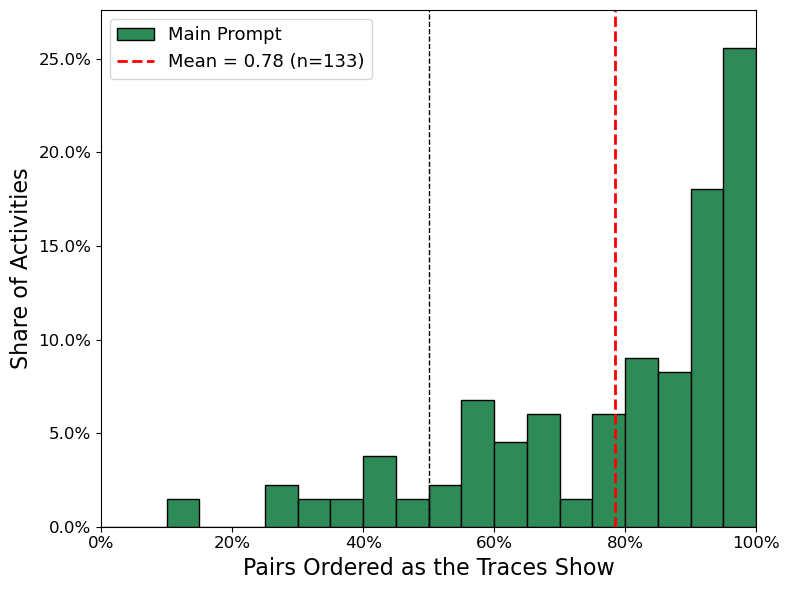

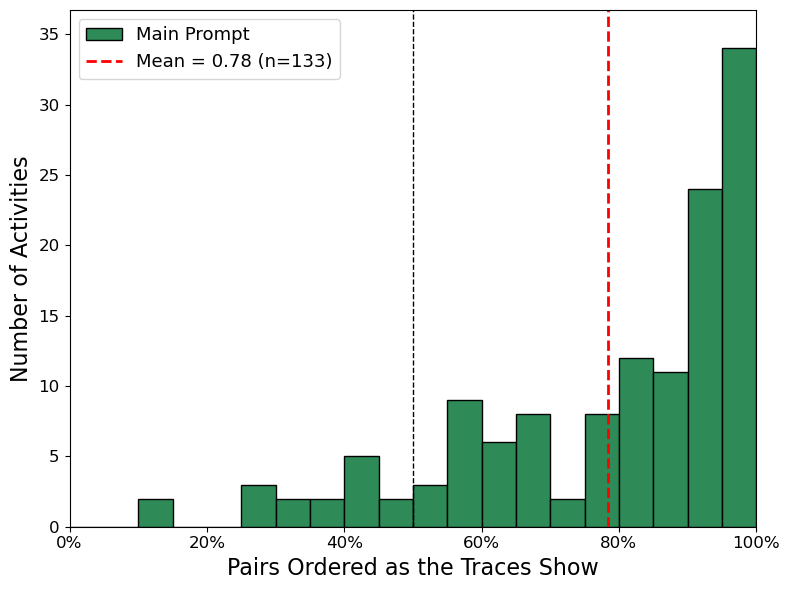

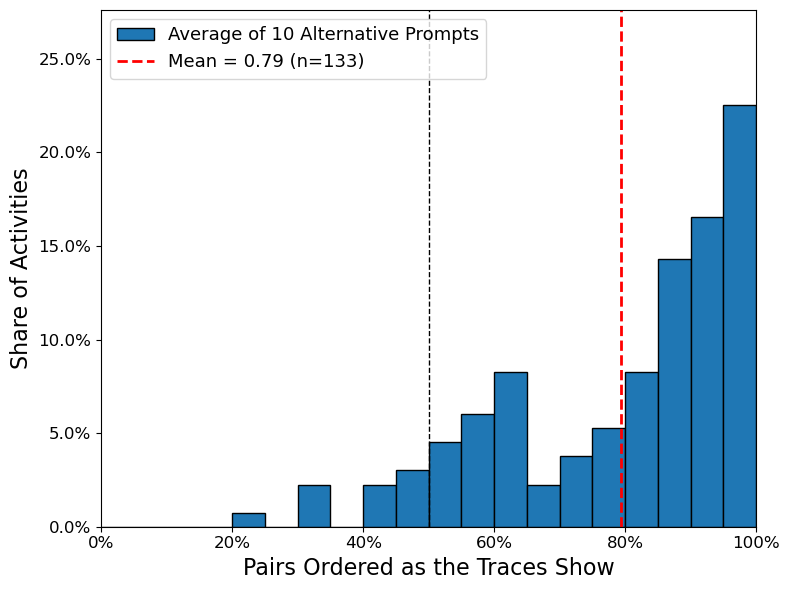

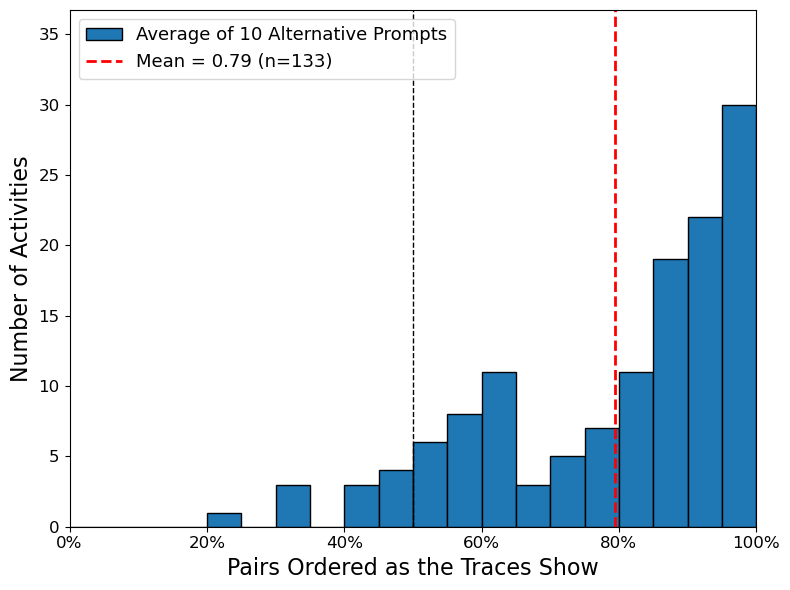

In [11]:
# Per-activity accuracy: share of an activity's determinate pairs ordered as the traces show
det = pairs[pairs['is_determinate']].copy()
long = pd.concat([det.rename(columns={'act_x': 'activity'})[['log', 'prompt', 'activity', 'correct']],
                  det.rename(columns={'act_y': 'activity'})[['log', 'prompt', 'activity', 'correct']]])
act = (long.groupby(['log', 'prompt', 'activity'])['correct'].agg(['size', 'mean'])
       .rename(columns={'size': 'n_pairs', 'mean': 'accuracy'}).reset_index())

act_main = act[act['prompt'] == MAIN_PROMPT][['log', 'activity', 'n_pairs', 'accuracy']]
act_alt = (act[act['prompt'].isin(ALT_PROMPTS)].groupby(['log', 'activity'])['accuracy'].mean()
           .reset_index().rename(columns={'accuracy': 'accuracy'}))
act_main.to_csv(f"{output_data_path}/activity_accuracy_main.csv", index=False)
act_alt.to_csv(f"{output_data_path}/activity_accuracy_alt.csv", index=False)
print(f"activities: {len(act_main)} across {act_main['log'].nunique()} logs")
print(f"  main prompt        mean {act_main['accuracy'].mean():.3f} | median {act_main['accuracy'].median():.3f} "
      f"| share above 0.5 {(act_main['accuracy'] > 0.5).mean():.1%} | share == 1 {(act_main['accuracy'] == 1).mean():.1%}")
print(f"  10-prompt average  mean {act_alt['accuracy'].mean():.3f} | median {act_alt['accuracy'].median():.3f} "
      f"| share above 0.5 {(act_alt['accuracy'] > 0.5).mean():.1%} | share == 1 {(act_alt['accuracy'] == 1).mean():.1%}")

EL_BINS = np.linspace(0, 1, 21)
EL_PANELS = [(act_main, 'Main Prompt', 'main', 'seagreen'),
             (act_alt,  'Average of 10 Alternative Prompts', 'alt', 'tab:blue')]
EL_YMAX = {s: max((np.histogram(d['accuracy'], bins=EL_BINS)[0] / (len(d) if s else 1)).max()
                  for d, *_ in EL_PANELS) for s in (True, False)}

def eventlog_distribution_figure(d, lab, tag, color, as_share):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(d['accuracy'], bins=EL_BINS, weights=np.ones(len(d)) / len(d) if as_share else None,
            color=color, edgecolor='black', label=lab)
    ax.axvline(d['accuracy'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Mean = {d['accuracy'].mean():.2f} (n={len(d)})")
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, EL_YMAX[as_share] * 1.08)
    if as_share:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("Pairs Ordered as the Traces Show", fontsize=16)
    ax.set_ylabel("Share of Activities" if as_share else "Number of Activities", fontsize=16)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=13, loc='upper left')
    fig.tight_layout()
    fig.savefig(f"{output_plot_path}/activity_accuracy_{tag}_{'share' if as_share else 'count'}.png",
                dpi=300, bbox_inches='tight')
    plt.show()

for d, lab, tag, color in EL_PANELS:
    for as_share in [True, False]:
        eventlog_distribution_figure(d, lab, tag, color, as_share)

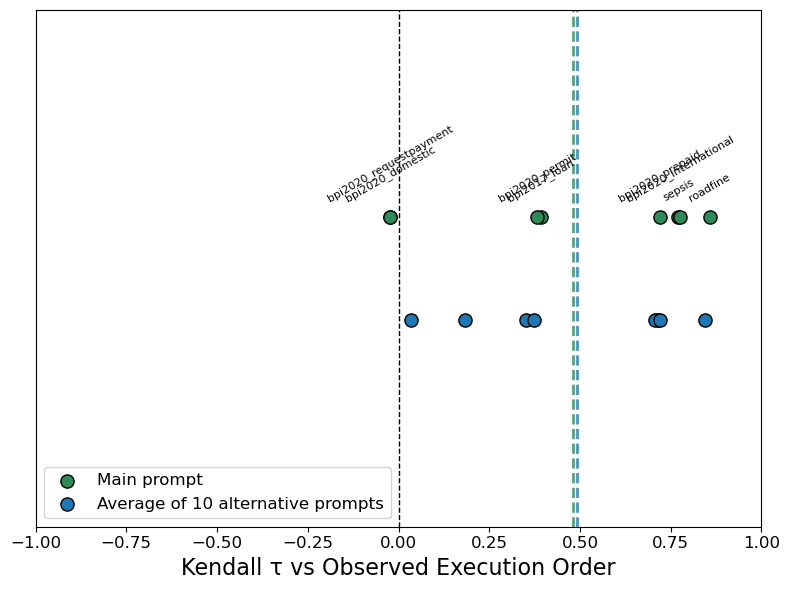

In [12]:
# Log-level Kendall tau: eight observations, so a dot plot rather than a histogram
fig, ax = plt.subplots(figsize=(8, 6))
for col, lab, color, off in [('tau_main', 'Main prompt', 'seagreen', 0.10),
                             ('tau_alt_mean', 'Average of 10 alternative prompts', 'tab:blue', -0.10)]:
    ax.scatter(res[col], np.full(len(res), off), s=90, color=color, edgecolor='black', zorder=3, label=lab)
    ax.axvline(res[col].mean(), color=color, ls='--', lw=2, alpha=0.8)
for _, r in res.iterrows():
    ax.annotate(r['log'], (r['tau_main'], 0.10), textcoords='offset points', xytext=(0, 11),
                ha='center', fontsize=8, rotation=30)
ax.axvline(0, color='black', ls='--', lw=1)
ax.set_xlim(-1, 1); ax.set_ylim(-0.5, 0.5); ax.set_yticks([])
ax.set_xlabel("Kendall τ vs Observed Execution Order", fontsize=16)
ax.tick_params(labelsize=12); ax.legend(fontsize=12, loc='lower left')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/tau_by_log_dotplot.png", dpi=300, bbox_inches='tight')
plt.show()

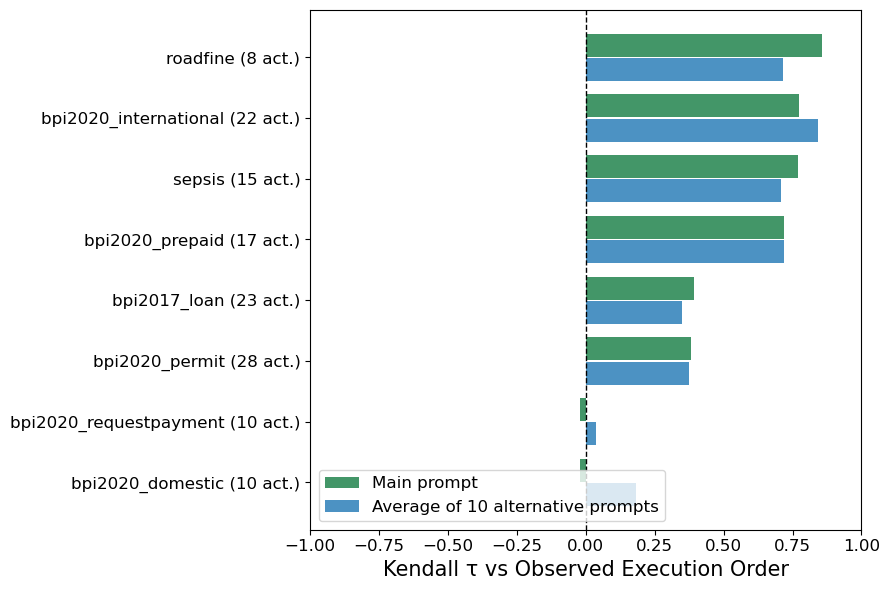

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
d = res.sort_values('tau_main')
y = np.arange(len(d))
ax.barh(y + 0.20, d['tau_main'], height=0.38, color='seagreen', alpha=0.9, label='Main prompt')
ax.barh(y - 0.20, d['tau_alt_mean'], height=0.38, color='tab:blue', alpha=0.8,
        label='Average of 10 alternative prompts')
ax.set_yticks(y)
ax.set_yticklabels([f"{r['log']} ({r['n_activities']} act.)" for _, r in d.iterrows()], fontsize=11)
ax.axvline(0, color='black', ls='--', lw=1)
ax.set_xlim(-1, 1)
ax.set_xlabel("Kendall τ vs Observed Execution Order", fontsize=15)
ax.tick_params(labelsize=12); ax.legend(fontsize=12, loc='lower left')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/tau_by_log.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
def fmt(v, f='{:.3f}'):
    return '' if pd.isna(v) else f.format(v)

sm = pair_stats(main_pairs); sa = pair_stats(alt_pairs)
tex = [r"\setlength{\tabcolsep}{8pt}", r"\small",
       r"\begin{tabular}{lcc}", r"\toprule",
       r" & Main prompt & 10 alternative prompts \\",
       r"\cmidrule(lr){2-3}",
       r" & (1) & (2) \\", r"\midrule", r"\addlinespace",
       r"\multicolumn{3}{l}{\textit{Pairwise precedence accuracy against observed execution (null 0.5)}} \\",
       r"\addlinespace",
       f"\\quad All activity pairs & {fmt(sm['accuracy_all_pairs'])} & {fmt(sa['accuracy_all_pairs'])} \\\\",
       f"\\quad Determinate pairs only & {fmt(sm['accuracy_determinate'])} & {fmt(sa['accuracy_determinate'])} \\\\",
       f"\\quad Weighted by determinacy & {fmt(sm['accuracy_weighted'])} & {fmt(sa['accuracy_weighted'])} \\\\",
       f"\\quad Adjacent pairs only & {fmt(sm['accuracy_adjacent'])} & {fmt(sa['accuracy_adjacent'])} \\\\",
       r"\addlinespace", r"\hline\\[-1.25em]",
       r"\multicolumn{3}{l}{\textit{Log-level Kendall $\tau$ against the observed ordering}} \\",
       r"\addlinespace",
       f"\\quad Mean across logs & {fmt(res['tau_main'].mean(), '{:+.3f}')} & {fmt(res['tau_alt_mean'].mean(), '{:+.3f}')} \\\\",
       f"\\quad Median across logs & {fmt(res['tau_main'].median(), '{:+.3f}')} & {fmt(res['tau_alt_mean'].median(), '{:+.3f}')} \\\\",
       f"\\quad Random ordering (null) & {fmt(res['tau_null_mean'].mean(), '{:+.3f}')} & {fmt(res['tau_null_mean'].mean(), '{:+.3f}')} \\\\",
       r"\hline\\[-1.25em]",
       f"Event logs & {len(res)} & {len(res)} \\\\",
       f"Activity pairs & {int(sm['n_pairs']):,} & {int(sa['n_pairs']):,} \\\\",
       f"Determinate pairs & {int(sm['n_determinate']):,} & {int(sa['n_determinate']):,} \\\\",
       f"Cases & {res['n_cases'].sum():,} & {res['n_cases'].sum():,} \\\\",
       r"\bottomrule", r"\end{tabular}"]

with open(f"{output_table_path}/eventlog_ordering_validation.tex", 'w') as f:
    f.write("\n".join(tex) + "\n")
print("\n".join(tex))
print("\nSaved:")
for f in sorted(os.listdir(output_data_path)):
    print("  data  ->", f"{output_data_path}/{f}")
for f in sorted(os.listdir(output_plot_path)):
    print("  plot  ->", f"{output_plot_path}/{f}")

\setlength{\tabcolsep}{8pt}
\small
\begin{tabular}{lcc}
\toprule
 & Main prompt & 10 alternative prompts \\
\cmidrule(lr){2-3}
 & (1) & (2) \\
\midrule
\addlinespace
\multicolumn{3}{l}{\textit{Pairwise precedence accuracy against observed execution (null 0.5)}} \\
\addlinespace
\quad All activity pairs & 0.788 & 0.791 \\
\quad Determinate pairs only & 0.789 & 0.792 \\
\quad Weighted by determinacy & 0.788 & 0.792 \\
\quad Adjacent pairs only & 0.679 & 0.699 \\
\addlinespace
\hline\\[-1.25em]
\multicolumn{3}{l}{\textit{Log-level Kendall $\tau$ against the observed ordering}} \\
\addlinespace
\quad Mean across logs & +0.481 & +0.491 \\
\quad Median across logs & +0.556 & +0.540 \\
\quad Random ordering (null) & -0.002 & -0.002 \\
\hline\\[-1.25em]
Event logs & 8 & 8 \\
Activity pairs & 1,178 & 11,780 \\
Determinate pairs & 1,124 & 11,240 \\
Cases & 215,715 & 215,715 \\
\bottomrule
\end{tabular}

Saved:
  data  -> ../data/computed_objects/eventlog_ordering/activity_accuracy_alt.csv
  data

In [15]:
print("=== Face validity: observed order vs the model's order, main prompt ===")
for name in ['roadfine', 'sepsis', 'bpi2020_domestic']:
    if name not in logs or name not in gpt_pos[MAIN_PROMPT]:
        continue
    gp = gpt_pos[MAIN_PROMPT][name]
    print(f"\n### {name}: {LOGS[name]}   (tau = {res.loc[res['log'] == name, 'tau_main'].iloc[0]:+.2f})")
    print(f"    {'observed order':<52} GPT")
    for i, a in enumerate(logs[name]['activities'], 1):
        print(f"    {i:>2}. {a[:48]:<49} {gp[a]:>2}")

print("\n=== The pairs the model gets wrong that are most determinate in the data (main prompt) ===")
worst = main_pairs[~main_pairs['correct']].nlargest(12, 'determinacy')
for _, r in worst.iterrows():
    print(f"  determinacy {r['determinacy']:.2f} | {r['log']:<22} {r['act_x'][:32]} -> {r['act_y'][:32]}")

=== Face validity: observed order vs the model's order, main prompt ===

### roadfine: Road traffic fine management by a local police force   (tau = +0.86)
    observed order                                       GPT
     1. Create Fine                                        1
     2. Send Fine                                          2
     3. Insert Fine Notification                           3
     4. Insert Date Appeal to Prefecture                   4
     5. Add penalty                                        7
     6. Send Appeal to Prefecture                          5
     7. Payment                                            6
     8. Send for Credit Collection                         8

### sepsis: Treatment of patients with suspected sepsis in a hospital emergency department   (tau = +0.77)
    observed order                                       GPT
     1. ER Registration                                    1
     2. ER Triage                                          2
    

## Reading the results

This is the strongest of the three validation exercises in the project, because the benchmark is observed
rather than documented and because the data identify which orderings are real.

The pair-level result is the one to quote. Restricting to activity pairs that the traces show are strictly
ordered removes exactly the objection the APQC appendix has to concede, namely that some of the measured
disagreement is disagreement with an arbitrary convention rather than with a workflow. What remains is a
clean question with a clean answer: when a real organisation reliably does $x$ before $y$, how often does
the ordering instrument say so.

Two limitations remain and should be stated in any writeup.

First, the eight logs are not a random sample of work. They are administrative and clinical processes with
recorded case identifiers, which is what makes them loggable in the first place, and they under-represent
the judgment-heavy occupations where AI exposure is concentrated.

Second, activity labels in a log are the strings an information system emits, not task statements. Some are
terse (`A_Concept`) and some encode the actor rather than the action (`Declaration APPROVED by
ADMINISTRATION`). This cuts against the model, which sees less context than an O\*NET task statement
provides, so accuracy here is if anything a conservative estimate of what the instrument achieves on the
task descriptions actually used in the paper.